# Quantium Virtual Internship - Retail Strategy and Analytics - Task 1

## Task Requirements
- Examine transaction data – look for inconsistencies, missing data across the data set, outliers, correctly identified category items, numeric data across all tables. If you determine any anomalies make the necessary changes in the dataset and save it. Having clean data will help when it comes to your analysis. 

- Examine customer data – check for similar issues in the customer data, look for nulls and when you are happy merge the transaction and customer data together so it’s ready for the analysis ensuring you save your files along the way.

- Data analysis and customer segments – in your analysis make sure you define the metrics – look at total sales, drivers of sales, where the highest sales are coming from etc. Explore the data, create charts and graphs as well as noting any interesting trends and/or insights you find. These will all form part of our report to Julia. 

- Deep dive into customer segments – define your recommendation from your insights, determine which segments we should be targeting, if packet sizes are relative and form an overall conclusion based on your analysis. 

- Make sure you save your analysis in the CSV files and your visualisations – we will need them for our report. If you could work on this analysis and send me your initial findings by end of next week that would be great. 

### Step 1:  Examining and Cleaning Datasets

- Customer dataset has no missing values. It consists of a primary key column, (numeric, as expected) and two categorical columns. Changes to dataset: 
1. renaming all columns to lower case
2. Setting lifestage column to sentence case

- Transaction dataset has no null values. However:
1. The column names are in all caps and short text form. They have been set to lower case and full word form for ease of access and readability puroposes.
2. The date column is expressed in integer (Excel) format. A sale_date colum in date time format has been created
3. The distribution of numerical columns, product_quantity and total sales is skewed to the right: the difference between Max(value) and Q3 is > 1.5* IQR. Outlier transactions have been inspected and excluded.
4. Some products in the dataset include salsa - pattern observed is salsa comes in 300g packaging (different from potato chips). These data points have been removed.

### Step 2: Key Insights/ Findings
1. The top 3 most popular brands, in order of revenue are Kettle, Smiths and Doritos
![brand by revenue](revenue_brand_name.png)

2. The 3 most frequently bought pack sizes, in order are 175g, 150g and 134g.
 ![transactions by pack size](txns_pack_size.png)
 
3. The top 3 segments that contribute to revenue are older families in the budget segment, young singles/couples in the mainstream segment and retirees in the mainstream segment
![revenue segments](revenue_segments.png)

4. With a p-value of 0, we can confidently assume that the average price spent by young singles/couples in mainstream is higher than that of young singles/couples in premium.

5. Kettle, Doritos and Pringles are the preferred brands for the young singles mainstream group - the group that generates the highest revenue


9.The most popular combinations of purchases according to market basket analysis:
- Red Rock Deli SR Salsa & Mzzrlla 150g and Smiths Crinkle Cut Chips Chicken 170g
- Natural Chip Co Tmato Hrb&Spce 175g and Pringles Sthrn FriedChicken 134g
- Kettle Chilli 175g and Doritos Mexicana 170g


In [3]:
# load packages for data cleaning and analysis
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt 
import re

In [4]:
# load in customer dataset, save as pandas data frame
customer = pd.read_csv('QVI_purchase_behaviour.csv')
customer.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [5]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [6]:
# inspect customer dataframe column names, null values and distribution of values
customer.info()
column_names = ['loyalty_card_number', 'lifestage', 'premium_customer']
customer.columns = column_names
customer.columns
customer["lifestage"].value_counts()
customer["lifestage"] = customer["lifestage"].str.title()
customer["lifestage"].head()
customer["lifestage"] = customer["lifestage"].str.title()
customer["premium_customer"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


Mainstream    29245
Budget        24470
Premium       18922
Name: premium_customer, dtype: int64

In [7]:
# load in transaction dataset, save as pandas data frame
transaction = pd.read_csv('QVI_transaction_data.csv')
transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [8]:
# inspect transaction dataframe for column names, data types, null values and distribution of values
transaction.info()
column_names_ = ['date_int','store_number','loyalty_card_number','transaction_id','product_number', 'product_name','product_quantity', 'total_sales']
transaction.columns = column_names_

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [9]:
# convert date from integer based on origin date
transaction["sale_date"] = pd.to_datetime('1899-12-30') + pd.to_timedelta(transaction["date_int"],'D')
transaction["sale_date"].map(lambda t: t.strftime('%Y-%m-%d'))
transaction["sale_date"].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: sale_date, dtype: datetime64[ns]

In [10]:
# inspect distribution of numerical columns: quantity and sales 
transaction[['product_quantity', 'total_sales']].describe()


,product_quantity,total_sales
count,264836.000000,264836.000000
mean,1.907309,7.304200
std,0.643654,3.083226
min,1.000000,1.500000
25%,2.000000,5.400000
50%,2.000000,7.400000
75%,2.000000,9.200000
max,200.000000,650.000000


In [11]:
# inspect outlier
transaction[transaction["product_quantity"] ==200]

,date_int,store_number,loyalty_card_number,transaction_id,product_number,product_name,product_quantity,total_sales,sale_date
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,2018-08-19
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,2019-05-20


In [12]:
# drop any outliers
outlier_check = np.quantile(transaction["product_quantity"], 0.75) + (1.5 * (np.quantile(transaction["product_quantity"], 0.75) - np.quantile(transaction["product_quantity"], 0.25)) )

transaction = transaction [transaction["product_quantity"] < 200]
transaction[['product_quantity', 'total_sales']].describe()

,product_quantity,total_sales
count,264834.000000,264834.000000
mean,1.905813,7.299346
std,0.343436,2.527241
min,1.000000,1.500000
25%,2.000000,5.400000
50%,2.000000,7.400000
75%,2.000000,9.200000
max,5.000000,29.500000


In [13]:
# verify spread of sales transactions over time, isolate missing transaction date
num_transactions = transaction.groupby("sale_date").agg({"transaction_id":"count"})
date_series = pd.DataFrame(pd.date_range(start='2018-07-01', end='2019-06-30'), columns=['date'])
date_series["date"].map(lambda t: t.strftime('%Y-%m-%d'))
txns_over_time = date_series.merge(num_transactions,left_on ='date' ,right_on = 'sale_date', how ='left')
txns_over_time[txns_over_time["transaction_id"].isnull()]

,date,transaction_id
177,2018-12-25,NaN


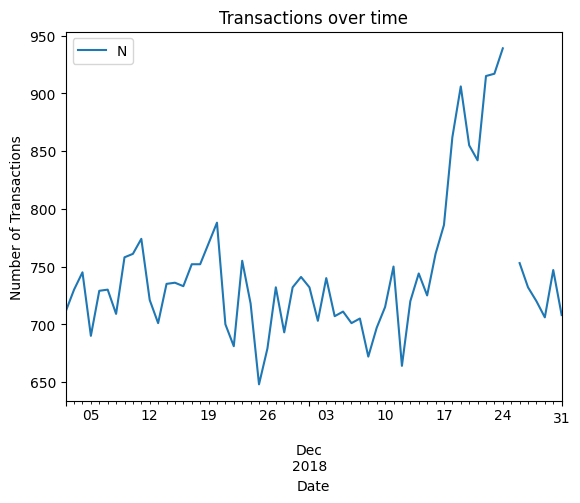

In [14]:
tx = txns_over_time[(txns_over_time["date"] >'2018-11-01') &(txns_over_time["date"] < '2019-01-01') ]
tx.plot(x="date", y= "transaction_id")
plt.title("Transactions over time")
plt.legend("Number of Transactions")
plt.ylabel("Number of Transactions")
plt.xlabel("Date")
plt.show()

In [15]:
import re

# product name column inspection
transaction["products"]= transaction["product_name"].str.split().apply(lambda x: ' '.join(re.findall(r'[a-zA-Z]+', ' '.join(x))))
transaction["unique_word"] = [[i] + re.findall(r'([A-Z][a-z]*\d*)', i) for i in transaction["products"]]
transaction["total_words"] = [len(x) for x in transaction["unique_word"]]
res = transaction.drop("product_name", 1).explode("unique_word").groupby(["unique_word"])["total_words"].agg(['count', 'sum']).sort_values("sum", ascending = False)
res

,count,sum
unique_word,,
Chips,49770,294333
Kettle,41288,225918
R,26772,193812
Salt,30884,189452
Smiths,28860,178863
...,...,...
Originl,1441,5764
Woolworths Medium Salsa g,1430,5720
Burger Rings g,1564,4692


In [16]:
# remove salsa from dataset
df = transaction[(transaction["product_name"].str.contains('Salsa', regex=False, case=False, na=False)) & (transaction["product_name"].str.contains('300g', regex=False, case=False, na=False)) == False]
df

,date_int,store_number,loyalty_card_number,transaction_id,product_number,product_name,product_quantity,total_sales,sale_date,products,unique_word,total_words
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,2018-10-17,Natural Chip Compny SeaSalt g,"[Natural Chip Compny SeaSalt g, Natural, Chip,...",6
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,2019-05-14,CCs Nacho Cheese g,"[CCs Nacho Cheese g, C, Cs, Nacho, Cheese]",5
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,2019-05-20,Smiths Crinkle Cut Chips Chicken g,"[Smiths Crinkle Cut Chips Chicken g, Smiths, C...",6
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,2018-08-17,Smiths Chip Thinly S Cream Onion g,"[Smiths Chip Thinly S Cream Onion g, Smiths, C...",7
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,2018-08-18,Kettle Tortilla ChpsHny Jlpno Chili g,"[Kettle Tortilla ChpsHny Jlpno Chili g, Kettle...",7
...,...,...,...,...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,2019-03-09,Kettle Sweet Chilli And Sour Cream g,"[Kettle Sweet Chilli And Sour Cream g, Kettle,...",7
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,2018-08-13,Tostitos Splash Of Lime g,"[Tostitos Splash Of Lime g, Tostitos, Splash, ...",5
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,2018-11-06,Doritos Mexicana g,"[Doritos Mexicana g, Doritos, Mexicana]",3
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,2018-12-27,Doritos Corn Chip Mexican Jalapeno g,"[Doritos Corn Chip Mexican Jalapeno g, Doritos...",6


In [17]:
# order pack sizes by purchase frequency, which size packs are the most popular? 
df["pack_sizes"] =df["product_name"].str.replace('[^\d\.]','', regex=True).astype(str)
df["pack_sizes"] = df["pack_sizes"] + "g"
sales_by_pack_size = df.groupby("pack_sizes")["transaction_id"].count().reset_index().sort_values("transaction_id")

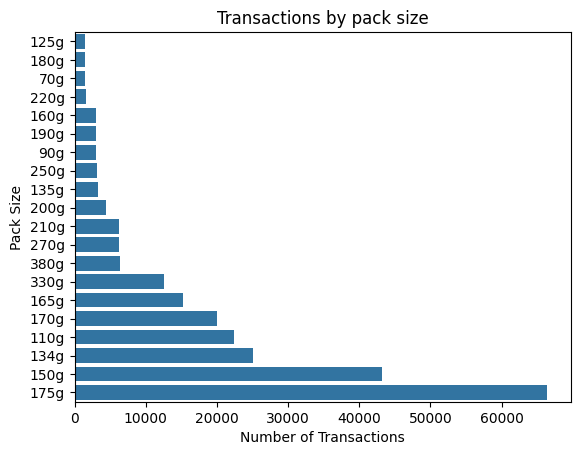

In [18]:
sns.barplot(y="pack_sizes", x="transaction_id", data=sales_by_pack_size)
plt.title("Transactions by pack size")
plt.ylabel("Pack Size")
plt.xlabel("Number of Transactions")
plt.savefig('txns_pack_size')
plt.show()

In [19]:
# get a list of chip brands 
df["brand"] = df["product_name"].str.split().str.get(0)
df["brand"].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'French', 'RRD', 'Tostitos', 'Cheetos',
       'Woolworths', 'Snbts', 'Sunbites'], dtype=object)

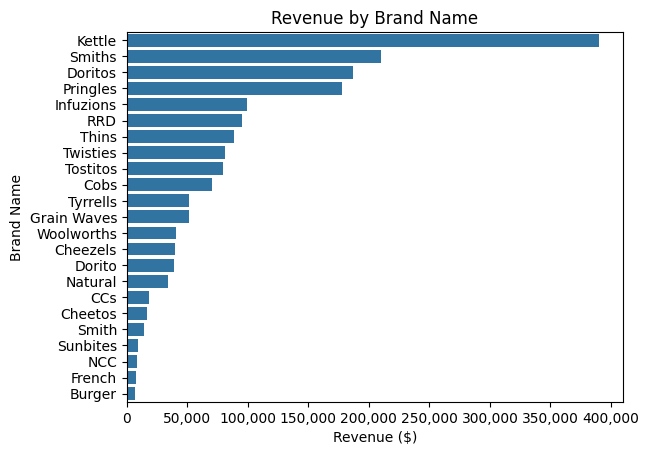

In [20]:

import matplotlib as mpl
#clean up chip brands
replace_values = {'Grain' : 'Grain Waves', 'GrnWves' : 'Grain Waves', 'WW':'Woolworths','Infzns':'Infuzions', 'Red':'RRD', 'Snbts':'Sunbites'}   

df["brand"]= df["brand"].replace(replace_values)
brand_group = df.groupby("brand")["total_sales","product_quantity"].agg("sum").reset_index().sort_values(by ="total_sales", ascending=False)
#which brands are the most popular/bring in the most revenue?
sns.barplot(x="total_sales", y="brand",  data=brand_group)
plt.title("Revenue by Brand Name")
plt.ylabel("Brand Name")
plt.xlabel("Revenue ($)")
plt.gca().xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.savefig('revenue_brand_name')
plt.show()


In [21]:
# combine customer and transaction data
data = df.merge(customer, on = 'loyalty_card_number', how ='left')
data.columns
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 249668 entries, 0 to 249667
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date_int             249668 non-null  int64         
 1   store_number         249668 non-null  int64         
 2   loyalty_card_number  249668 non-null  int64         
 3   transaction_id       249668 non-null  int64         
 4   product_number       249668 non-null  int64         
 5   product_name         249668 non-null  object        
 6   product_quantity     249668 non-null  int64         
 7   total_sales          249668 non-null  float64       
 8   sale_date            249668 non-null  datetime64[ns]
 9   products             249668 non-null  object        
 10  unique_word          249668 non-null  object        
 11  total_words          249668 non-null  int64         
 12  pack_sizes           249668 non-null  object        
 13  brand         

In [22]:
#create segments based on sales contributions
segment = data.groupby(['lifestage','premium_customer']).agg({"loyalty_card_number":"count","product_quantity":"sum", "total_sales":"sum"}).sort_values("total_sales", ascending=False).reset_index()
segment.rename(columns={"loyalty_card_number": "num_customers", "product_quantity": "qty_sold", "total_sales": "revenue"},inplace=True)
segment["quantity_per_customer"] = segment["qty_sold"]/segment["num_customers"]
segment["avg_chip_price"] = segment["revenue"]/segment["qty_sold"]
segment

,lifestage,premium_customer,num_customers,qty_sold,revenue,quantity_per_customer,avg_chip_price
0,Older Families,Budget,21808,42425,158379.95,1.945387,3.733175
1,Young Singles/Couples,Mainstream,19705,36509,148337.20,1.852778,4.063031
2,Retirees,Mainstream,20202,38114,146328.75,1.886645,3.839239
3,Young Families,Budget,17995,34936,130919.05,1.941428,3.747397
4,Older Singles/Couples,Budget,17345,33204,128683.80,1.914327,3.875551
5,Older Singles/Couples,Mainstream,17276,33018,125737.10,1.911206,3.808138
6,Older Singles/Couples,Premium,16742,32044,124463.05,1.913989,3.884130
7,Retirees,Budget,14364,27192,106606.20,1.893066,3.920499
8,Older Families,Mainstream,13411,26132,97280.85,1.948550,3.722671
9,Retirees,Premium,12368,23513,91951.95,1.901116,3.910686


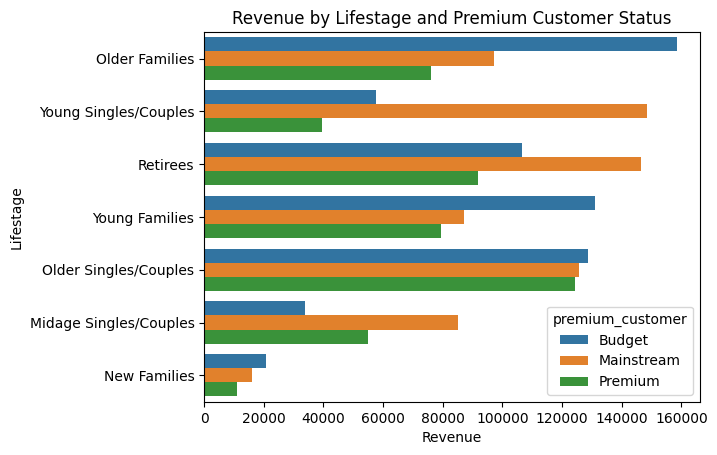

In [23]:
## insights: which segments bring in the most revenue and sales volumes?
sns.barplot( x="revenue",y="lifestage",hue="premium_customer", data=segment)
plt.title("Revenue by Lifestage and Premium Customer Status")
plt.ylabel("Lifestage")
plt.xlabel("Revenue")
plt.savefig('revenue_segments')
plt.show()

In [24]:
# is the avg price spent on products significantly different between the two segments?
data["unit_price"] = data["total_sales"]/data["product_quantity"]
test_1 = data[['lifestage', 'premium_customer','unit_price', 'brand','product_quantity', 'total_sales','pack_sizes']]
var_1 = test_1[(test_1["premium_customer"] == "Mainstream") & (test_1["lifestage"].str.contains('Young Singles|Midage Singles')) ]
var_2 = test_1[(test_1["premium_customer"] == "Premium") & (test_1["lifestage"].str.contains('Young Singles|Midage Singles')) ]

In [25]:
from scipy import stats

print ("The t-statistic is %.3f and the p-value is %.3f." % stats.ttest_ind(var_1['unit_price'], var_2['unit_price'], alternative= "greater"))

The t-statistic is 29.654 and the p-value is 0.000.


With a p-value of 0, we can confidently assume that the average price spent by young singles/couples in mainstream is higher than that of young singles/couples in premium.

In [26]:
# which brands are preferred by young mainstream segment?
young_ms =var_1[var_1["lifestage"].str.contains('Young Singles')]
young_ms.groupby("brand").agg({"product_quantity":"sum","total_sales":"sum"}).sort_values("total_sales", ascending=False)
plt.savefig('revenue_segments')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 640x480 with 0 Axes>

In [27]:
# which pack size is preferred by young mainstream segment?
young_ms.groupby('pack_sizes').agg({"product_quantity":"sum","total_sales":"sum"}).sort_values("total_sales", ascending=False)

,product_quantity,total_sales
pack_sizes,,
175g,9237,37967.9
150g,5993,23701.2
134g,4326,16006.2
110g,3850,14630.0
330g,2220,12654.0
170g,2926,11893.4
165g,2016,7395.0
380g,1165,7175.9
270g,1153,5303.8


In [28]:
#isolate customers that purchased more than 1 product to perform market basket analysis
transactions_grouped = data[["transaction_id","product_name","loyalty_card_number", "sale_date"]] 

pt = pd.pivot_table(transactions_grouped,
                    values=["product_name"],
                    index=["transaction_id","loyalty_card_number", "sale_date"],
                    aggfunc={"product_name": list})
pt["num_products"] = [len(x) for x in pt["product_name"]]
df1 = pt[pt["num_products"] >1 ].reset_index()
df1.head(15)

,transaction_id,loyalty_card_number,sale_date,product_name,num_products
0,517,1446,2019-06-20,"[Pringles Sthrn FriedChicken 134g, Kettle Tort...",2
1,628,2034,2018-12-20,"[Sunbites Whlegrn Crisps Frch/Onin 90g, Inf...",2
2,1142,3008,2018-08-26,"[Twisties Cheese 270g, Cobs Popd Swt/Chlli...",2
3,1162,3014,2019-01-09,"[Pringles SourCream Onion 134g, Dorito Corn C...",3
4,1498,3095,2019-06-25,"[Kettle Sea Salt And Vinegar 175g, Pringle...",2
5,1819,3172,2019-02-04,"[Kettle Sensations Camembert & Fig 150g, Tyr...",2
6,1843,3177,2019-04-03,"[Doritos Corn Chip Southern Chicken 150g, Dori...",2
7,1894,3188,2019-04-02,"[Pringles Barbeque 134g, Pringles Chicken ...",2
8,2031,3216,2019-03-01,"[Smiths Crnkle Chip Orgnl Big Bag 380g, Pring...",2
9,2148,3239,2018-08-18,"[Kettle 135g Swt Pot Sea Salt, Pringles SourCr...",2


In [29]:
#create data frame to track multi-purchases by shopping basket
df1["single_transaction"]= df1["loyalty_card_number"].astype(str)+"_"+df1["sale_date"].astype(str)+"_" +df1["transaction_id"].astype(str)
#df1.drop([], axis=1, inplace=True)
#df2 = pd.crosstab(df1["single_transaction"], df1["product_name"])
df2 = df1["product_name"].str.get_dummies(',').groupby(df1["single_transaction"]).sum()


In [30]:
# convert shopping basket to binary df
def encode(item_freq):
    res = 0
    if item_freq > 0:
        res = 1
    return res
    
basket_input = df2.applymap(encode)


In [31]:

# build the Apriori Algorithm for Market Basket Analysis
import sys
!{sys.executable} -m pip install mlxtend
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules,apriori

frequent_itemsets = apriori(basket_input, min_support=0.001, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift")

rules.head()

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.9 MB/s eta 0:00:00


/home/repl/.local/lib/python3.8/site-packages/mlxtend/frequent_patterns/fpcommon.py:109: DeprecationWarning:

DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type



,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,( 'Burger Rings 220g']),(['Pringles Original Crisps 134g'),0.008655,0.013981,0.001332,0.153846,11.003663,0.001211,1.165295,0.917058
1,(['Pringles Original Crisps 134g'),( 'Burger Rings 220g']),0.013981,0.008655,0.001332,0.095238,11.003663,0.001211,1.095697,0.922012
2,( 'Cheezels Cheese 330g']),(['Doritos Cheese Supreme 330g'),0.015313,0.012650,0.001332,0.086957,6.874142,0.001138,1.081384,0.867816
3,(['Doritos Cheese Supreme 330g'),( 'Cheezels Cheese 330g']),0.012650,0.015313,0.001332,0.105263,6.874142,0.001138,1.100533,0.865475
4,( 'Cheezels Cheese 330g']),(['Doritos Corn Chips Nacho Cheese 170g'),0.015313,0.016644,0.001332,0.086957,5.224348,0.001077,1.077008,0.821163


In [32]:
#To get the most frequent item combinations in the entire dataset, let’s sort the dataset by support, confidence, and lift:
rules.sort_values(["support", "confidence","lift"],axis = 0, ascending = False).head(8)

# most common purchases:
#[" 'Red Rock Deli SR    Salsa & Mzzrlla 150g']"] ["['Smiths Crinkle Cut  Chips Chicken 170g'"]
#["['Natural Chip Co     Tmato Hrb&Spce 175g'"][" 'Pringles Sthrn FriedChicken 134g']"]
#["['Kettle Chilli 175g'"] [" 'Doritos Mexicana    170g']"]
#["['WW Sour Cream &OnionStacked Chips 160g'"] [" 'Infuzions Mango     Chutny Papadums 70g']"]







,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
131,( 'Red Rock Deli SR Salsa & Mzzrlla 150g']),(['Smiths Crinkle Cut Chips Chicken 170g'),0.005326,0.005992,0.001997,0.375000,62.583333,0.001965,1.590413,0.989290
130,(['Smiths Crinkle Cut Chips Chicken 170g'),( 'Red Rock Deli SR Salsa & Mzzrlla 150g']),0.005992,0.005326,0.001997,0.333333,62.583333,0.001965,1.492011,0.989953
118,(['Natural Chip Co Tmato Hrb&Spce 175g'),( 'Pringles Sthrn FriedChicken 134g']),0.006658,0.015313,0.001997,0.300000,19.591304,0.001895,1.406696,0.955317
39,(['Kettle Chilli 175g'),( 'Doritos Mexicana 170g']),0.009321,0.009987,0.001997,0.214286,21.457143,0.001904,1.260017,0.962366
38,( 'Doritos Mexicana 170g']),(['Kettle Chilli 175g'),0.009987,0.009321,0.001997,0.200000,21.457143,0.001904,1.238349,0.963013
45,(['WW Sour Cream &OnionStacked Chips 160g'),( 'Infuzions Mango Chutny Papadums 70g']),0.009987,0.012650,0.001997,0.200000,15.810526,0.001871,1.234188,0.946200
35,( 'Doritos Corn Chips Nacho Cheese 170g']),(['Pringles Original Crisps 134g'),0.009987,0.013981,0.001997,0.200000,14.304762,0.001858,1.232523,0.939475
82,(['Infuzions SourCream&Herbs Veg Strws 110g'),( 'Kettle Sweet Chilli And Sour Cream 175g']),0.010652,0.012650,0.001997,0.187500,14.822368,0.001863,1.215200,0.942575


In [33]:
#import notebook_as_pdf
#import nbconvert
#import pyppeteer


#!jupyter nbconvert --to webpdf --allow-chromium-download 'qvi_data_tasks.ipynb'
# --stdout display(HTML('\n'.join(task_1)))


# Task 2: Experimentation and Uplift testing

In [34]:
# create year-month column
data['year_month'] = data['sale_date'].apply(lambda x: str(x.year) + '-' + str(x.month))
data.head(20)

,date_int,store_number,loyalty_card_number,transaction_id,product_number,product_name,product_quantity,total_sales,sale_date,products,unique_word,total_words,pack_sizes,brand,lifestage,premium_customer,unit_price,year_month
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,2018-10-17,Natural Chip Compny SeaSalt g,"[Natural Chip Compny SeaSalt g, Natural, Chip,...",6,175g,Natural,Young Singles/Couples,Premium,3.00,2018-10
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,2019-05-14,CCs Nacho Cheese g,"[CCs Nacho Cheese g, C, Cs, Nacho, Cheese]",5,175g,CCs,Midage Singles/Couples,Budget,2.10,2019-5
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,2019-05-20,Smiths Crinkle Cut Chips Chicken g,"[Smiths Crinkle Cut Chips Chicken g, Smiths, C...",6,170g,Smiths,Midage Singles/Couples,Budget,1.45,2019-5
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,2018-08-17,Smiths Chip Thinly S Cream Onion g,"[Smiths Chip Thinly S Cream Onion g, Smiths, C...",7,175g,Smiths,Midage Singles/Couples,Budget,3.00,2018-8
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,2018-08-18,Kettle Tortilla ChpsHny Jlpno Chili g,"[Kettle Tortilla ChpsHny Jlpno Chili g, Kettle...",7,150g,Kettle,Midage Singles/Couples,Budget,4.60,2018-8
5,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,2019-05-16,Smiths Crinkle Chips Salt Vinegar g,"[Smiths Crinkle Chips Salt Vinegar g, Smiths, ...",6,330g,Smiths,Midage Singles/Couples,Budget,5.70,2019-5
6,43601,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,2019-05-16,Grain Waves Sweet Chilli g,"[Grain Waves Sweet Chilli g, Grain, Waves, Swe...",5,210g,Grain Waves,Midage Singles/Couples,Budget,3.60,2019-5
7,43332,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,2018-08-20,Doritos Corn Chip Mexican Jalapeno g,"[Doritos Corn Chip Mexican Jalapeno g, Doritos...",6,150g,Doritos,Midage Singles/Couples,Budget,3.90,2018-8
8,43330,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,2018-08-18,Grain Waves Sour Cream Chives G,"[Grain Waves Sour Cream Chives G, Grain, Waves...",7,210g,Grain Waves,Midage Singles/Couples,Budget,3.60,2018-8
9,43602,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,2019-05-17,Smiths Crinkle Chips Salt Vinegar g,"[Smiths Crinkle Chips Salt Vinegar g, Smiths, ...",6,330g,Smiths,Midage Singles/Couples,Budget,5.70,2019-5


In [35]:
data.to_csv(r'C:\Users\Tasha\Desktop\qvi_task1.csv', index=False, header=True)

In [36]:
# calculate store-level metrics
#store_metrics = data.groupby(["store_number","year_month"]).agg(monthly_revenue=("total_sales", "sum"),num_customers =("loyalty_card_number", "nunique"), avg_unit_price =("unit_price", "mean"), num_transactions =("transaction_id", "count"), num_packs=("product_quantity", "sum")).sort_values(by=["monthly_revenue","avg_unit_price" ]).reset_index()
#store_metrics["txns_per_cust"] = store_metrics["num_transactions"]/store_metrics["num_customers"]
#store_metrics["packs_per_cust"]= store_metrics["num_packs"]/store_metrics["num_customers"]

# filter to the pre-trial period and stores with full observation periods
#num_obs_period = store_metrics.groupby("store_number")["year_month"].agg("count").reset_index()
#only_full = num_obs_period[num_obs_period["year_month"] == 12 ]
#stores_full_obs = only_full["store_number"].to_list()
#store_metrics[store_metrics["store_number"].isin(stores_full_obs)]

In [37]:
#store_metric[store_metrics["store_number"]]